In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir("/content/drive/MyDrive")

['Colab Notebooks',
 'GP1_Lit_Tracking.gsheet',
 'ecg data new version',
 'ECG-Data-200 Images Per Set',
 'ProjectDataSet',
 'Project DataSet',
 'swin_ecg_97.pth',
 'swin_features_97.csv',
 'swin_features_97.pt',
 'Fusion',
 'MobilnetGAl.ipynb',
 'نسخة من ECGTrial.ipynb']

In [ ]:
os.listdir("/content/drive/MyDrive/ProjectDataSet")

['Data',
 'ECGdata_patches_2x2',
 'dataset_split',
 'dataset_split_per_class',
 'mobile_convnext_fused.pth',
 'confusion_matrix_high_resmobile+conv fusio.png',
 'classification_reportMobileNet + ConvNeXt.txt']

In [ ]:
os.listdir("/content/drive/MyDrive/ProjectDataSet/dataset_split_per_class")

['Test', 'Val', 'Train']

Classes: ['HB', 'MI', 'Normal', 'PMI']
Train grouped samples: 742
Val grouped samples: 94
Test grouped samples: 91
Per-patch features: torch.Size([8, 4, 576])
Fused features: torch.Size([8, 2304])
Example: patch feature dim = 576
Example: fused dim = 2304
[Before training] Val Acc=0.1809 | F1 Macro=0.1183 | F1 Micro=0.1809
Epoch 1/5 | Train Loss=1.0837 | Val Loss=1.4350 | Train Acc=0.2412 | Val Acc=0.2021
Epoch 2/5 | Train Loss=0.5088 | Val Loss=1.1536 | Train Acc=0.5714 | Val Acc=0.5532
Epoch 3/5 | Train Loss=0.2375 | Val Loss=0.5567 | Train Acc=0.8571 | Val Acc=0.7766
Epoch 4/5 | Train Loss=0.1338 | Val Loss=0.2771 | Train Acc=0.9690 | Val Acc=0.9362
Epoch 5/5 | Train Loss=0.0674 | Val Loss=0.1896 | Train Acc=0.9906 | Val Acc=0.9468

===== TEST RESULTS =====
Test Acc   : 0.9890
Test F1Macro: 0.9871
Test F1Micro: 0.9890


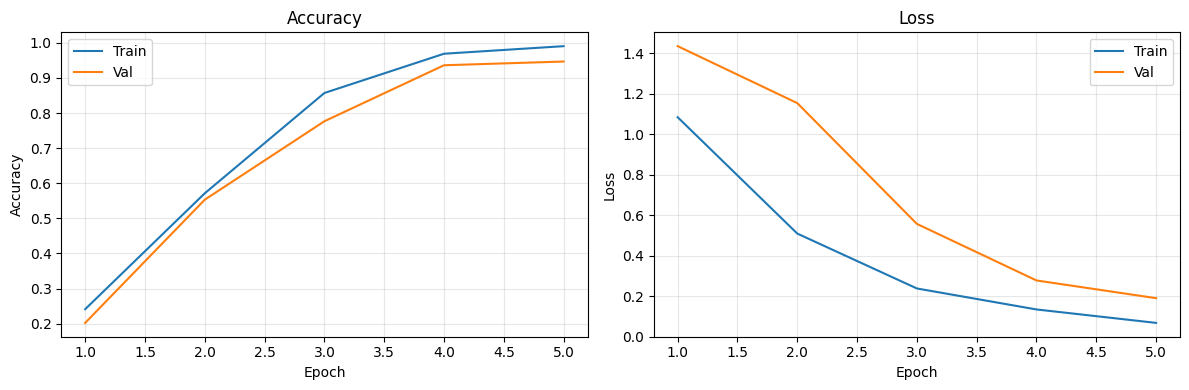

In [ ]:
import os, glob, re
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from sklearn.metrics import f1_score, accuracy_score

# =========================
# 0) Paths
# =========================
ROOT = "/content/drive/MyDrive/ProjectDataSet/dataset_split_per_class"
TRAIN_DIR = os.path.join(ROOT, "Train")
VAL_DIR   = os.path.join(ROOT, "Val")
TEST_DIR  = os.path.join(ROOT, "Test")

# =========================
# 1) Transforms
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # بما إن الباتش أصلاً 224 غالبًا، بس نخليها آمنة
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# =========================
# 2) Helpers: parse patch id + base id
# =========================
def parse_patch_id(filename: str):
    """
    Extract patch index from filename.
    Supports: _p1 _p2 _p3 _p4  OR  patch1 patch2 patch3 patch4
    Return 1..4 or None
    """
    name = filename.lower()
    m = re.search(r'[_\-]p([1-4])\b', name)
    if m: return int(m.group(1))
    m = re.search(r'patch[_\-]?([1-4])\b', name)
    if m: return int(m.group(1))
    return None

def base_id(filename: str):
    """
    Remove patch suffix to get the original sample id.
    Example: MI(12)_p3.jpg -> MI(12)
             sampleA_patch2.png -> sampleA
    """
    name = os.path.splitext(filename)[0]
    name = re.sub(r'[_\-]p[1-4]\b', '', name, flags=re.IGNORECASE)
    name = re.sub(r'patch[_\-]?[1-4]\b', '', name, flags=re.IGNORECASE)
    return name

# =========================
# 3) Dataset: group 4 patches into one sample
# =========================
class ECGPatchGroupDataset(Dataset):
    def __init__(self, split_dir, transform=None, require_4=True):
        self.split_dir = split_dir
        self.transform = transform
        self.require_4 = require_4

        # classes are subfolders
        self.classes = sorted([d for d in os.listdir(split_dir)
                               if os.path.isdir(os.path.join(split_dir, d))])
        if len(self.classes) == 0:
            raise ValueError(f"No class folders found inside: {split_dir}")

        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}

        # Build groups: (class, base_id) -> {patch_id: path}
        groups = {}
        for cls in self.classes:
            cls_dir = os.path.join(split_dir, cls)
            imgs = []
            for ext in ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"):
                imgs += glob.glob(os.path.join(cls_dir, ext))
            for p in imgs:
                fn = os.path.basename(p)
                pid = parse_patch_id(fn)
                bid = base_id(fn)
                key = (cls, bid)
                if key not in groups:
                    groups[key] = {}
                if pid is not None:
                    groups[key][pid] = p

        # Keep only valid samples
        self.samples = []
        for (cls, bid), patch_map in groups.items():
            if require_4:
                if all(k in patch_map for k in [1,2,3,4]):
                    self.samples.append((cls, bid, patch_map))
            else:
                # allow any count >=1
                if len(patch_map) > 0:
                    self.samples.append((cls, bid, patch_map))

        if len(self.samples) == 0:
            raise ValueError(
                f"No grouped samples found in {split_dir}.\n"
                f"Check patch naming pattern (_p1.._p4 or patch1..4)."
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cls, bid, patch_map = self.samples[idx]
        y = self.class_to_idx[cls]

        # Load in fixed order p1..p4
        patches = []
        for pid in [1,2,3,4]:
            img_path = patch_map[pid]
            img = Image.open(img_path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            patches.append(img)

        # tensor: (4,3,224,224)
        x = torch.stack(patches, dim=0)
        return x, y, cls, bid

# =========================
# 4) Model: MobileNetV3 feature extractor + concat fusion
# =========================
class PatchFusionMobileNetV3(nn.Module):
    def __init__(self, num_classes, fusion="concat", pretrained=True):
        super().__init__()
        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        base = mobilenet_v3_small(weights=weights)

        # feature extractor up to avgpool
        self.features = base.features
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        # embedding dim = last channel of mobilenet v3 small
        # in torchvision it's usually 576
        self.embed_dim = 576

        self.fusion = fusion.lower()
        if self.fusion == "concat":
            fused_dim = self.embed_dim * 4
        elif self.fusion in ["sum","avg","mean","mul","product"]:
            fused_dim = self.embed_dim
        else:
            raise ValueError("fusion must be one of: concat, sum, avg, mul")

        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(fused_dim, num_classes)
        )

    def forward(self, x, return_features=False, verbose_shapes=False):
        """
        x: (B,4,3,224,224)
        """
        B, P, C, H, W = x.shape
        x = x.view(B*P, C, H, W)  # (B*4,3,224,224)

        f = self.features(x)      # (B*4, embed_dim, h, w)
        f = self.avgpool(f)       # (B*4, embed_dim, 1, 1)
        f = torch.flatten(f, 1)   # (B*4, embed_dim)

        # reshape back to patches
        f_patches = f.view(B, P, -1)  # (B,4,embed_dim)

        if verbose_shapes:
            print("Per-patch features:", f_patches.shape)  # (B,4,576)

        # Fusion
        if self.fusion == "concat":
            fused = f_patches.reshape(B, -1)  # (B, 4*embed_dim)
        elif self.fusion == "sum":
            fused = f_patches.sum(dim=1)      # (B, embed_dim)
        elif self.fusion in ["avg","mean"]:
            fused = f_patches.mean(dim=1)     # (B, embed_dim)
        elif self.fusion in ["mul","product"]:
            fused = f_patches.prod(dim=1)     # (B, embed_dim)

        if verbose_shapes:
            print("Fused features:", fused.shape)

        logits = self.classifier(fused)

        if return_features:
            return logits, f_patches, fused
        return logits

# =========================
# 5) Dataloaders
# =========================
train_ds = ECGPatchGroupDataset(TRAIN_DIR, transform=transform, require_4=True)
val_ds   = ECGPatchGroupDataset(VAL_DIR,   transform=transform, require_4=True)
test_ds  = ECGPatchGroupDataset(TEST_DIR,  transform=transform, require_4=True)

print("Classes:", train_ds.classes)
print("Train grouped samples:", len(train_ds))
print("Val grouped samples:", len(val_ds))
print("Test grouped samples:", len(test_ds))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# =========================
# 6) Train/Eval utilities
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(train_ds.classes)

model = PatchFusionMobileNetV3(num_classes=num_classes, fusion="concat", pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

@torch.no_grad()
def evaluate(loader, verbose_one_batch=False):
    model.eval()
    all_y, all_pred = [], []

    for i, (x, y, cls, bid) in enumerate(loader):
        x = x.to(device)
        y = y.to(device)

        # فقط أول batch نطبع الـ feature shapes للتأكد
        if verbose_one_batch and i == 0:
            logits, f_patches, fused = model(x, return_features=True, verbose_shapes=True)
            print("Example: patch feature dim =", f_patches.shape[-1])
            print("Example: fused dim =", fused.shape[-1])
        else:
            logits = model(x)

        pred = torch.argmax(logits, dim=1)
        all_y.extend(y.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())

    acc = accuracy_score(all_y, all_pred)
    f1_macro = f1_score(all_y, all_pred, average="macro")
    f1_micro = f1_score(all_y, all_pred, average="micro")
    return acc, f1_macro, f1_micro

@torch.no_grad()
def evaluate_loss(loader):
    model.eval()
    total_loss = 0

    for x, y, _, _ in loader:
        x = x.to(device)
        y = y.to(device)

        out = model(x)
        loss = criterion(out, y)
        total_loss += loss.item()

    return total_loss / len(loader)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_loss": []
}

def train_one_epoch():
    model.train()
    total_loss = 0.0
    for x, y, cls, bid in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / max(1, len(train_loader))

# =========================
# 7) Run training
# =========================
epochs = 5
val_acc, val_f1M, val_f1m = evaluate(val_loader, verbose_one_batch=True)
print(f"[Before training] Val Acc={val_acc:.4f} | F1 Macro={val_f1M:.4f} | F1 Micro={val_f1m:.4f}")


for ep in range(1, epochs+1):
    train_loss = train_one_epoch()

    train_acc, _, _ = evaluate(train_loader)

    val_acc, _, _ = evaluate(val_loader)
    val_loss = evaluate_loss(val_loader)
    # val_acc, val_f1M, val_f1m = evaluate(val_loader, verbose_one_batch=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_loss"].append(val_loss)

    print(f"Epoch {ep}/{epochs} | "
          f"Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | "
          f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

test_acc, test_f1M, test_f1m = evaluate(test_loader, verbose_one_batch=False)
print("\n===== TEST RESULTS =====")
print(f"Test Acc   : {test_acc:.4f}")
print(f"Test F1Macro: {test_f1M:.4f}")
print(f"Test F1Micro: {test_f1m:.4f}")

import matplotlib.pyplot as plt

def plot_train_test_curves(history: dict, title_suffix: str = "") -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_acc"], label="Train")
    axes[0].plot(epochs, history["val_acc"], label="Val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Accuracy" + title_suffix)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["train_loss"], label="Train")
    axes[1].plot(epochs, history["val_loss"], label="Val")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Loss" + title_suffix)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    out = "/content/plot_accuracy_loss_main.png"
    plt.savefig(out, dpi=150)
    plt.show()

plot_train_test_curves(history)


In [ ]:
MOBILE_SAVE_PATH = "/content/drive/MyDrive/Fusion/mobileNetv3_weights.pth"
torch.save(model.state_dict(), MOBILE_SAVE_PATH)
print(f"Saved: {MOBILE_SAVE_PATH}")

Saved: /content/drive/MyDrive/Fusion/mobileNetv3_weights.pth


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
test_acc, test_f1M, test_f1m = evaluate(test_loader, verbose_one_batch=False)

# نجمع y_true و y_pred لحساب التوتل
all_y = []
all_pred = []

model.eval()
with torch.no_grad():
    for x, y, _, _ in test_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        pred = torch.argmax(logits, dim=1)

        all_y.extend(y.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())

total_precision = precision_score(all_y, all_pred, average="weighted", zero_division=0)
total_recall = recall_score(all_y, all_pred, average="weighted", zero_division=0)
total_f1 = f1_score(all_y, all_pred, average="weighted", zero_division=0)

print("\n===== TOTAL TEST METRICS =====")
print(f"Accuracy        : {test_acc:.4f}")
print(f"Total Precision : {total_precision:.4f}")
print(f"Total Recall    : {total_recall:.4f}")
print(f"Total F1-score  : {total_f1:.4f}")


===== TOTAL TEST METRICS =====
Accuracy        : 0.9890
Total Precision : 0.9895
Total Recall    : 0.9890
Total F1-score  : 0.9890


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Confusion Matrix:
[[23  0  0  0]
 [ 0 23  0  0]
 [ 0  0 28  0]
 [ 0  1  0 16]]


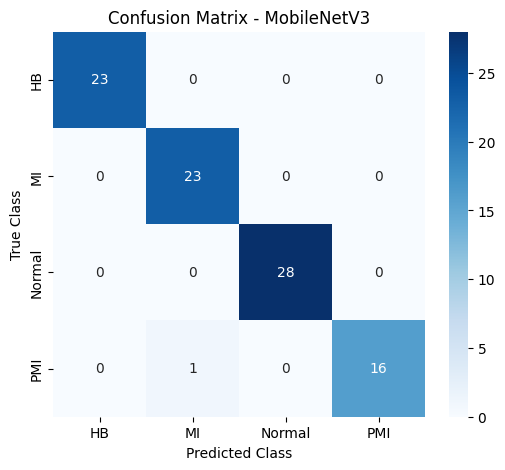

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
all_y = []
all_pred = []

model.eval()
with torch.no_grad():
    for x, y, _, _ in test_loader:
        x = x.to(device)

        logits = model(x)
        pred = torch.argmax(logits, dim=1)

        all_y.extend(y.numpy())
        all_pred.extend(pred.cpu().numpy())
        cm = confusion_matrix(all_y, all_pred)

print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - MobileNetV3")
plt.show()

In [ ]:
import time
import copy
import os
import torch.quantization

# =========================
# Green AI: FP32 vs Dynamic Quantization
# =========================

def evaluate_speed_accuracy(eval_model, loader, device_eval):
    eval_model.to(device_eval)
    eval_model.eval()

    correct = 0
    total = 0

    start_time = time.time()

    with torch.no_grad():
        for x, y, _, _ in loader:
            x = x.to(device_eval)
            y = y.to(device_eval)

            logits = eval_model(x)
            pred = torch.argmax(logits, dim=1)

            total += y.size(0)
            correct += (pred == y).sum().item()

    end_time = time.time()

    acc = 100 * correct / total
    inference_time = end_time - start_time

    return acc, inference_time


def get_model_size(model, filename="temp_model.pth"):
    torch.save(model.state_dict(), filename)
    size_mb = os.path.getsize(filename) / 1e6
    os.remove(filename)
    return size_mb


# =========================
# 1) BEFORE Dynamic Quantization
# =========================
print("\n===== BEFORE DYNAMIC QUANTIZATION (FP32) =====")

model_fp32 = copy.deepcopy(model).cpu()

acc_before, time_before = evaluate_speed_accuracy(
    model_fp32,
    test_loader,
    torch.device("cpu")
)

size_before = get_model_size(model_fp32)

print(f"Test Accuracy BEFORE: {acc_before:.2f}%")
print(f"Inference Time BEFORE: {time_before:.2f} seconds")
print(f"Model Size BEFORE: {size_before:.2f} MB")


# =========================
# 2) Apply Dynamic Quantization
# =========================
print("\nApplying Dynamic Quantization...")

quantized_model = torch.quantization.quantize_dynamic(
    model_fp32,
    {nn.Linear},
    dtype=torch.qint8
)

print("Dynamic Quantization applied successfully.")


# =========================
# 3) AFTER Dynamic Quantization
# =========================
print("\n===== AFTER DYNAMIC QUANTIZATION =====")

acc_after, time_after = evaluate_speed_accuracy(
    quantized_model,
    test_loader,
    torch.device("cpu")
)

size_after = get_model_size(quantized_model)

print(f"Test Accuracy AFTER: {acc_after:.2f}%")
print(f"Inference Time AFTER: {time_after:.2f} seconds")
print(f"Model Size AFTER: {size_after:.2f} MB")


# =========================
# 4) Green AI Summary
# =========================
size_reduction = ((size_before - size_after) / size_before) * 100
speedup = time_before / time_after if time_after > 0 else 0

print("\n===== GREEN AI SUMMARY =====")
print(f"Accuracy Change: {acc_after - acc_before:.2f}%")
print(f"Model Size Reduction: {size_reduction:.2f}%")
print(f"Speedup Factor: {speedup:.2f}x")


===== BEFORE DYNAMIC QUANTIZATION (FP32) =====
Test Accuracy BEFORE: 98.90%
Inference Time BEFORE: 4.34 seconds
Model Size BEFORE: 3.88 MB

Applying Dynamic Quantization...
Dynamic Quantization applied successfully.

===== AFTER DYNAMIC QUANTIZATION =====


/tmp/ipykernel_2133/3891709764.py:70: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Test Accuracy AFTER: 98.90%
Inference Time AFTER: 6.19 seconds
Model Size AFTER: 3.85 MB

===== GREEN AI SUMMARY =====
Accuracy Change: 0.00%
Model Size Reduction: 0.69%
Speedup Factor: 0.70x


In [ ]:
print("\n===== FEATURE COMPARISON (BEFORE vs AFTER DYNAMIC Q) =====")

# خذي batch واحد من التست
x_sample, y_sample, _, _ = next(iter(test_loader))

x_sample = x_sample.to("cpu")

# قبل (FP32)
model_fp32.eval()
with torch.no_grad():
    logits_fp32, f_patches_fp32, fused_fp32 = model_fp32(
        x_sample,
        return_features=True
    )

# بعد (Dynamic Quantized)
quantized_model.eval()
with torch.no_grad():
    logits_int8, f_patches_int8, fused_int8 = quantized_model(
        x_sample,
        return_features=True
    )

print("\n--- SHAPES ---")
print("Patch Features BEFORE:", f_patches_fp32.shape)
print("Patch Features AFTER :", f_patches_int8.shape)

print("Fused Features BEFORE:", fused_fp32.shape)
print("Fused Features AFTER :", fused_int8.shape)

# نحسب الفرق العددي
diff_patch = torch.mean(torch.abs(f_patches_fp32 - f_patches_int8)).item()
diff_fused = torch.mean(torch.abs(fused_fp32 - fused_int8)).item()

print("\n--- NUMERICAL DIFFERENCE ---")
print(f"Patch Features Difference: {diff_patch:.6f}")
print(f"Fused Features Difference: {diff_fused:.6f}")


===== FEATURE COMPARISON (BEFORE vs AFTER DYNAMIC Q) =====

--- SHAPES ---
Patch Features BEFORE: torch.Size([8, 4, 576])
Patch Features AFTER : torch.Size([8, 4, 576])
Fused Features BEFORE: torch.Size([8, 2304])
Fused Features AFTER : torch.Size([8, 2304])

--- NUMERICAL DIFFERENCE ---
Patch Features Difference: 0.000000
Fused Features Difference: 0.000000


In [ ]:
def get_ids(ds):
    ids = set()
    for cls, bid, patch_map in ds.samples:
        ids.add(bid)
    return ids

train_ids = get_ids(train_ds)
val_ids   = get_ids(val_ds)
test_ids  = get_ids(test_ds)

print("Train-Val overlap:", len(train_ids & val_ids))
print("Train-Test overlap:", len(train_ids & test_ids))
print("Val-Test overlap:", len(val_ids & test_ids))

print("Examples Train-Test:", list(train_ids & test_ids)[:10])

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0
Examples Train-Test: []


In [ ]:
from collections import Counter

def class_distribution(ds):
    labels = []
    for cls, bid, patch_map in ds.samples:
        labels.append(cls)
    return Counter(labels)

print("Train:", class_distribution(train_ds))
print("Val:", class_distribution(val_ds))
print("Test:", class_distribution(test_ds))

Train: Counter({'Normal': 227, 'MI': 192, 'HB': 185, 'PMI': 138})
Val: Counter({'Normal': 29, 'HB': 24, 'MI': 24, 'PMI': 17})
Test: Counter({'Normal': 28, 'HB': 23, 'MI': 23, 'PMI': 17})


In [ ]:
from torchvision.datasets import ImageFolder

class ImageFolderWithPaths(ImageFolder):

    def __getitem__(self, index):

        img, label = super().__getitem__(index)

        path = self.samples[index][0]

        return img, label, path